# 📊 **Exploratory Data Analysis — Bitcoin (BTC)**

### 🎯 **Objective**
Explore the Bitcoin **Gold dataset** to understand market behavior and identify patterns associated with **bearish reversals (crashes)**.

### ⚠️ **Target Definition**
A crash is defined as a price drop of more than **10% within the next 7 days**.

- `1` → Crash  
- `0` → No crash  

### 🔬 **EDA Focus**
1.  Distribution of the target (class balance)  
2.  BTC price with crash events  
3.  Drawdown analysis  
4.  Feature distributions  
5.  Correlation between features and target  

### 🚀 **Goal**
Identify signals and patterns that could help predict market reversals.

In [43]:
import math
import random
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

### **1. Distribution of the target (class balance)**  

In [10]:
df = pd.read_csv("../data/gold/market/btc_usdt_1d_features.csv", low_memory=False)

DF's infos

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3135 entries, 0 to 3134
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   open_time               3135 non-null   str    
 1   open                    3135 non-null   float64
 2   high                    3135 non-null   float64
 3   low                     3135 non-null   float64
 4   close                   3135 non-null   float64
 5   volume                  3135 non-null   float64
 6   quote_asset_volume      3135 non-null   float64
 7   number_of_trades        3135 non-null   int64  
 8   taker_buy_base_volume   3135 non-null   float64
 9   taker_buy_quote_volume  3135 non-null   float64
 10  return_1d               3135 non-null   float64
 11  return_7d               3135 non-null   float64
 12  volatility_7d           3135 non-null   float64
 13  volatility_30d          3112 non-null   float64
 14  drawdown                3135 non-null   float64
 15

Focus on target column

In [12]:
print(df["target"].value_counts(normalize=True), "\n\n", df["target"].value_counts())

target
False    0.974163
True     0.025837
Name: proportion, dtype: float64 

 target
False    3054
True       81
Name: count, dtype: int64


**Observation:**  
The dataset is imbalanced, with significantly more non-peak observations than peak events.

**Impact:**  
The model may be biased toward predicting the majority class (no peak), leading to misleading accuracy and poor detection of actual peaks (low recall and/or precision).

**Solution:**
- Use appropriate evaluation metrics (precision, recall, F1-score)  
- Apply class weighting to handle imbalance  
- Use resampling techniques (oversampling or undersampling)  
- Adjust the decision threshold to improve detection of peaks  

### **2. BTC price with crash events**

**Bitcoin Price Over Time**

In [13]:
figure=px.line(df, x="open_time", y="close", title="BTC/USDT Price Over Time")
figure.show()

**Bitcoin Price with Peak Events**

In [14]:
figure=px.line(df,x="open_time", y="close")

peaks = df[df["target"] == 1]

figure.add_scatter(
    x=peaks["open_time"], 
    y=peaks["close"],
    mode="markers",
    marker=dict(color="red", size=6),
    name="Peaks"
    )
figure.update_layout(title="BTC/USDT Price Over Time with Peaks")
figure.show()

**Observations:**
- Peaks are mostly located at local price maxima  
- Peaks often precede significant price declines  
- Strong alignment with major market cycles (bull → top → drop)  
- Some peaks occur during minor fluctuations (noise)  
- Overall, peak detection is consistent with market tops  
- Visual inspection confirms that most detected peaks align with actual market tops  
- The definition captures major turning points but may be slightly sensitive to short-term volatility  

**Price Behavior Around Peaks**

*Analyze the typical price pattern before and after randomly selected peak events, using relative returns centered at the peak (t = 0).*


In [27]:
NB_PEAKS_TO_DISPLAY = 5

peaks_position = random.sample(range(len(peaks)), NB_PEAKS_TO_DISPLAY)
random_peaks = peaks.iloc[peaks_position]

# 2 subplots (1 ligne, 2 colonnes)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Absolute Variation Around Peaks",
        "Relative Returns Around Peaks"
    ]
)

for index, row in random_peaks.iterrows():
    # skip bords
    if index < 7 or index > len(df) - 7:
        continue

    df_slice = df.iloc[index-7:index+7]

    x = list(range(-7, 7))

    # Absolute
    y_abs = df_slice["close"] - row["close"]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y_abs,
            mode="lines",
            opacity=0.4,
            showlegend=False
        ),
        row=1, col=1
    )

    # Relative
    y_rel = (df_slice["close"] / row["close"]) - 1

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y_rel,
            mode="lines",
            opacity=0.4,
            showlegend=False
        ),
        row=1, col=2
    )

# Layout
fig.update_layout(
    title="Price Behavior Around Peaks (Absolute vs Relative)",
)

fig.update_xaxes(title_text="Days Relative to Peak", row=1, col=1)
fig.update_xaxes(title_text="Days Relative to Peak", row=1, col=2)

fig.update_yaxes(title_text="Price Difference", row=1, col=1)
fig.update_yaxes(title_text="Return vs Peak", row=1, col=2)

fig.show()

**Observations:**
- Prices trend upward before labeled peak events  
- A local maximum is often observed around t = 0, but not always exactly aligned  
- In several cases, higher prices occur before t = 0 (e.g. +10%), indicating the true peak happened earlier  
- This shift is due to the target capturing the onset of a crash rather than the exact market top  
- A decline typically follows, confirming the reversal dynamic  
- The magnitude and timing of drops vary across events, reflecting market noise and heterogeneity  
- Overall, the pattern reflects a transition zone: late uptrend → peak region → decline  

### **3.  Drawdown analysis**

**Visualize drawdown over time**

In [16]:
figure= px.line(df, x="open_time", y="drawdown", title="BTC/USDT Price Over Time")
figure.add_scatter(
    x=peaks["open_time"],
    y=peaks["drawdown"],
    mode="markers",
    marker=dict(color="red", size=6),
    name="Peaks"
)
figure.show()


**Repartition of drawdown**

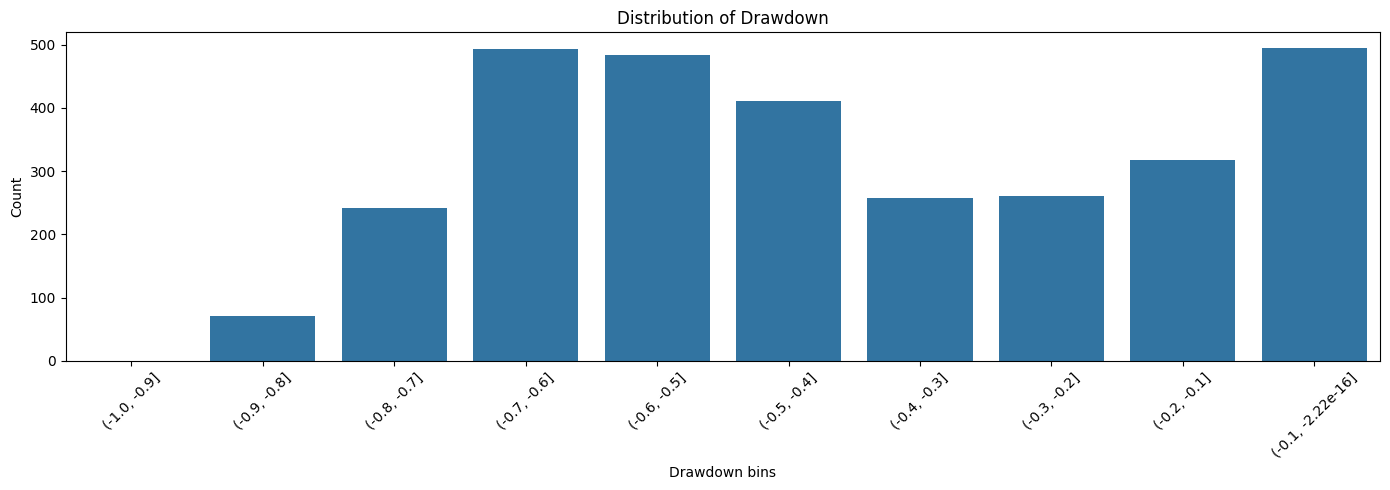

In [31]:
bins = np.arange(-1, 0.1, 0.1)
df["drawdown_bin"] = pd.cut(df["drawdown"], bins=bins)

counts = df["drawdown_bin"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(x=counts.index.astype(str), y=counts.values)

plt.title("Distribution of Drawdown")
plt.xlabel("Drawdown bins")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

df.drop(columns=["drawdown_bin"], inplace=True)

**Observations:**
- Drawdowns are **persistent and cyclical**, with clear bull/bear regimes.  
- Most values lie in **[-0.7, -0.4]**, indicating frequent medium-to-large corrections.  
- **Extreme crashes (< -0.8)** are rare but present → tail risk.  
- Peaks cluster near **0 drawdown**, showing repeated failed attempts at new highs.  
- Strong **regime-switching behavior** → non-IID, requires temporal modeling.

### **4.  Feature distributions**

Visualize distribution of each feature

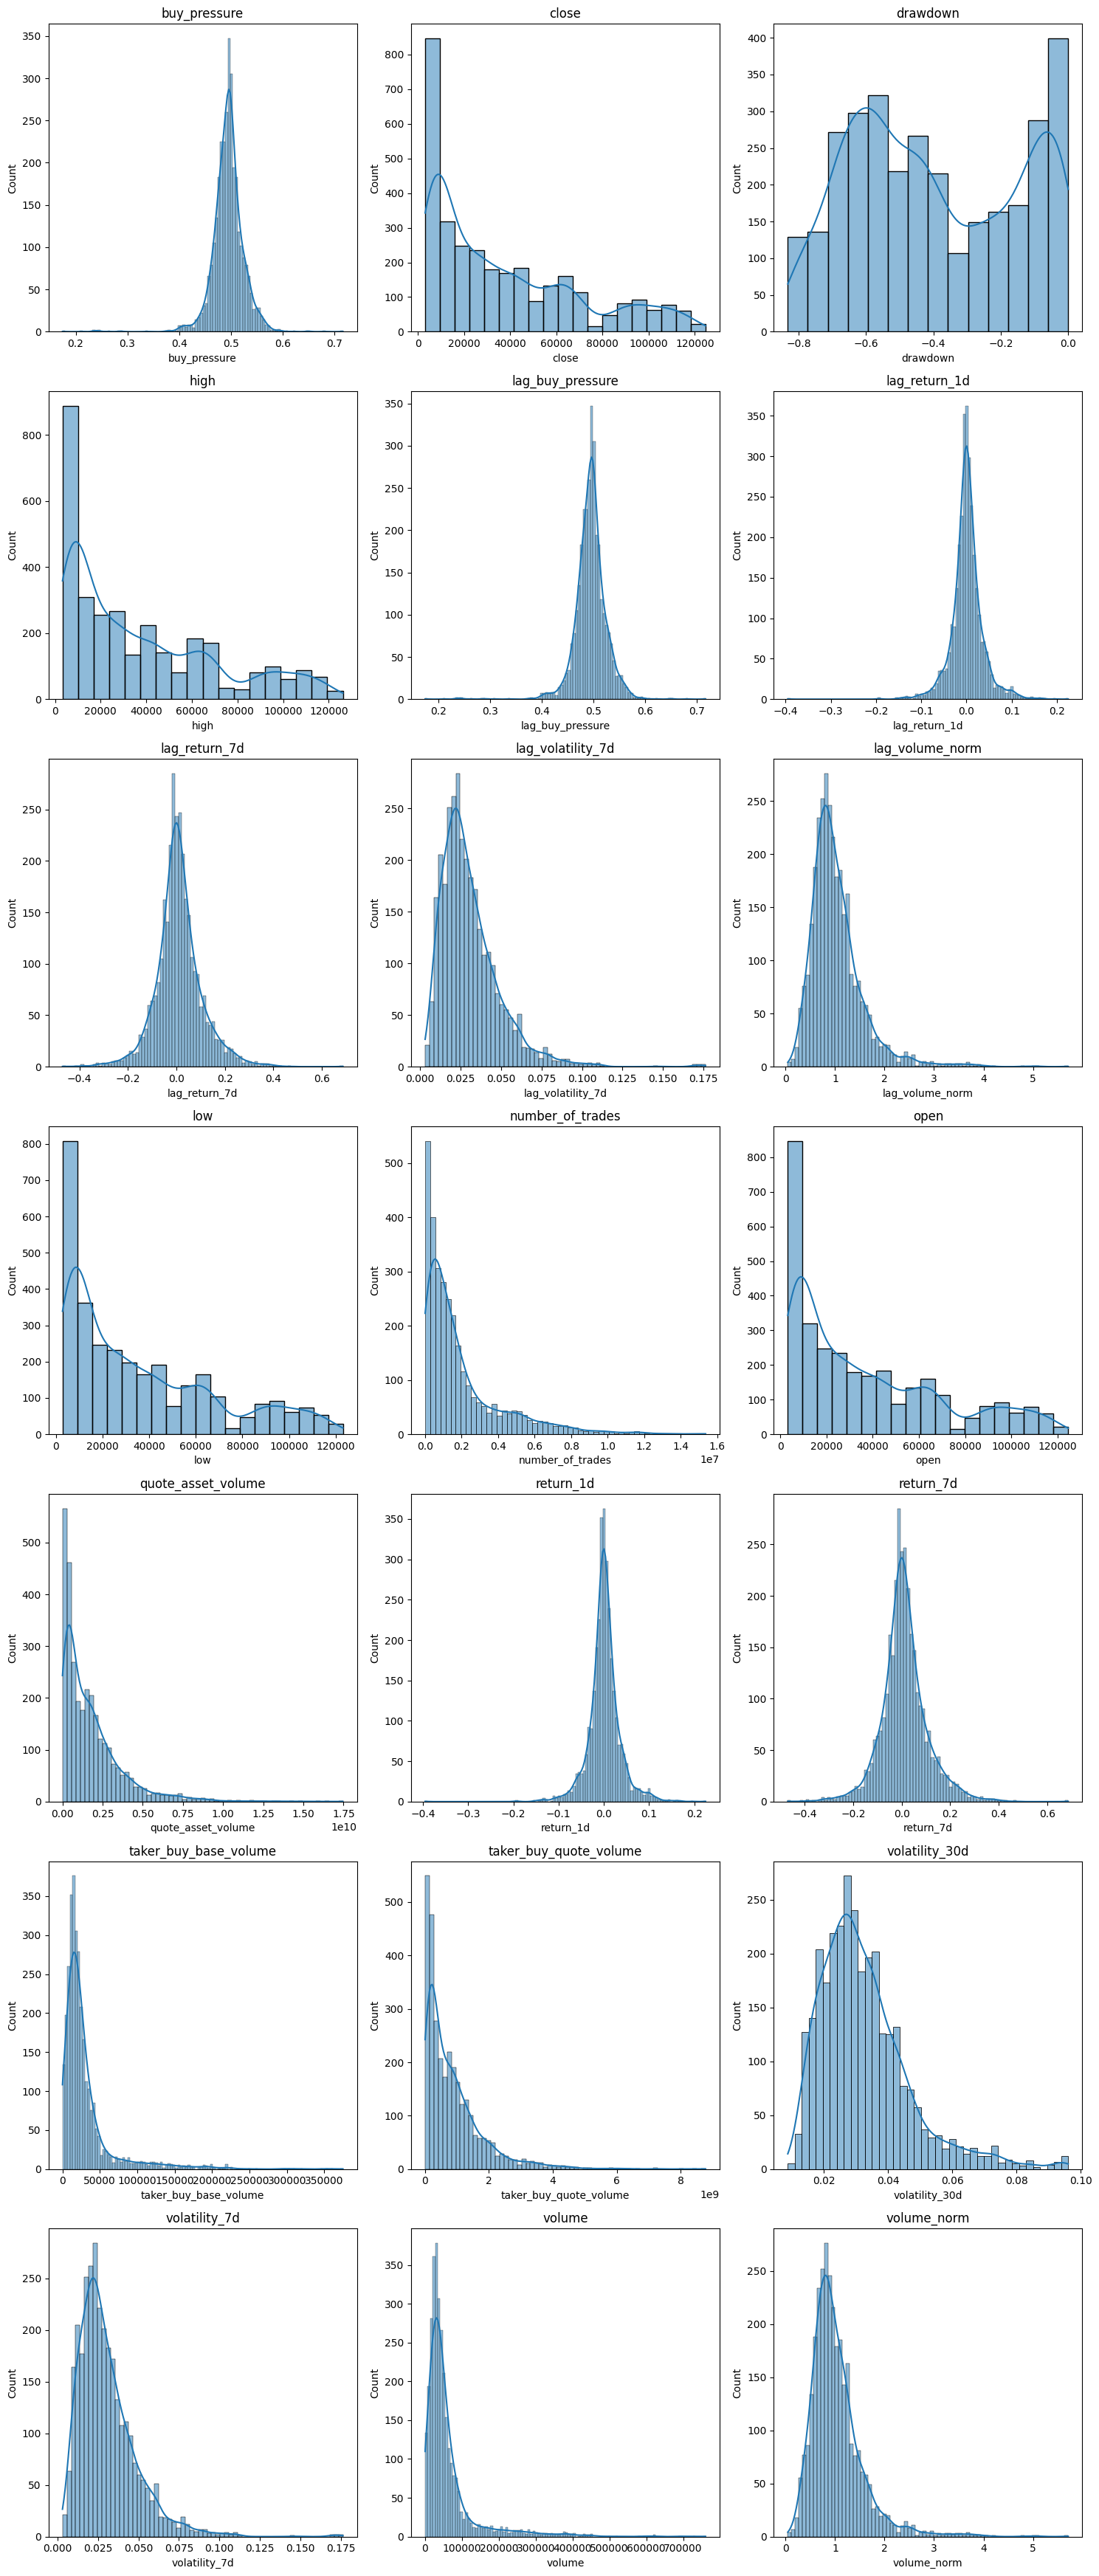

In [44]:
cols = list(df.columns.difference(["open_time", "target"]))

n_cols = 3  # nombre de graphes par ligne
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations**

- Most price/volume-related features (open, close, volume, trades) are **heavily right-skewed** → need log scaling.
- Returns (`return_1d`, `return_7d`) are **centered around 0 with fat tails** → typical financial distributions.
- Volatility features are **positively skewed** with clear concentration at low values → regime-dependent behavior.
- `drawdown` shows a **multi-modal distribution** → distinct market regimes (bull, correction, bear).
- Lagged features closely mirror original ones → **strong temporal autocorrelation**.
- `buy_pressure` is **approximately Gaussian around 0.5** → relatively stable feature.
- Volume-related features exhibit **extreme outliers** → potential need for clipping or normalization.

**Conclusion**

- Apply **log transforms** to price and volume features to reduce skewness.  
- Use **robust scaling and clipping** to handle fat tails and outliers.  
- Leverage **temporal features (lags, rolling stats)** as key predictive signals.  
- Keep `drawdown` as a **core feature** (captures market regimes).  
- Account for **class imbalance** with appropriate metrics and weighting.  

**Compare distributions between peaks and non-peaks**

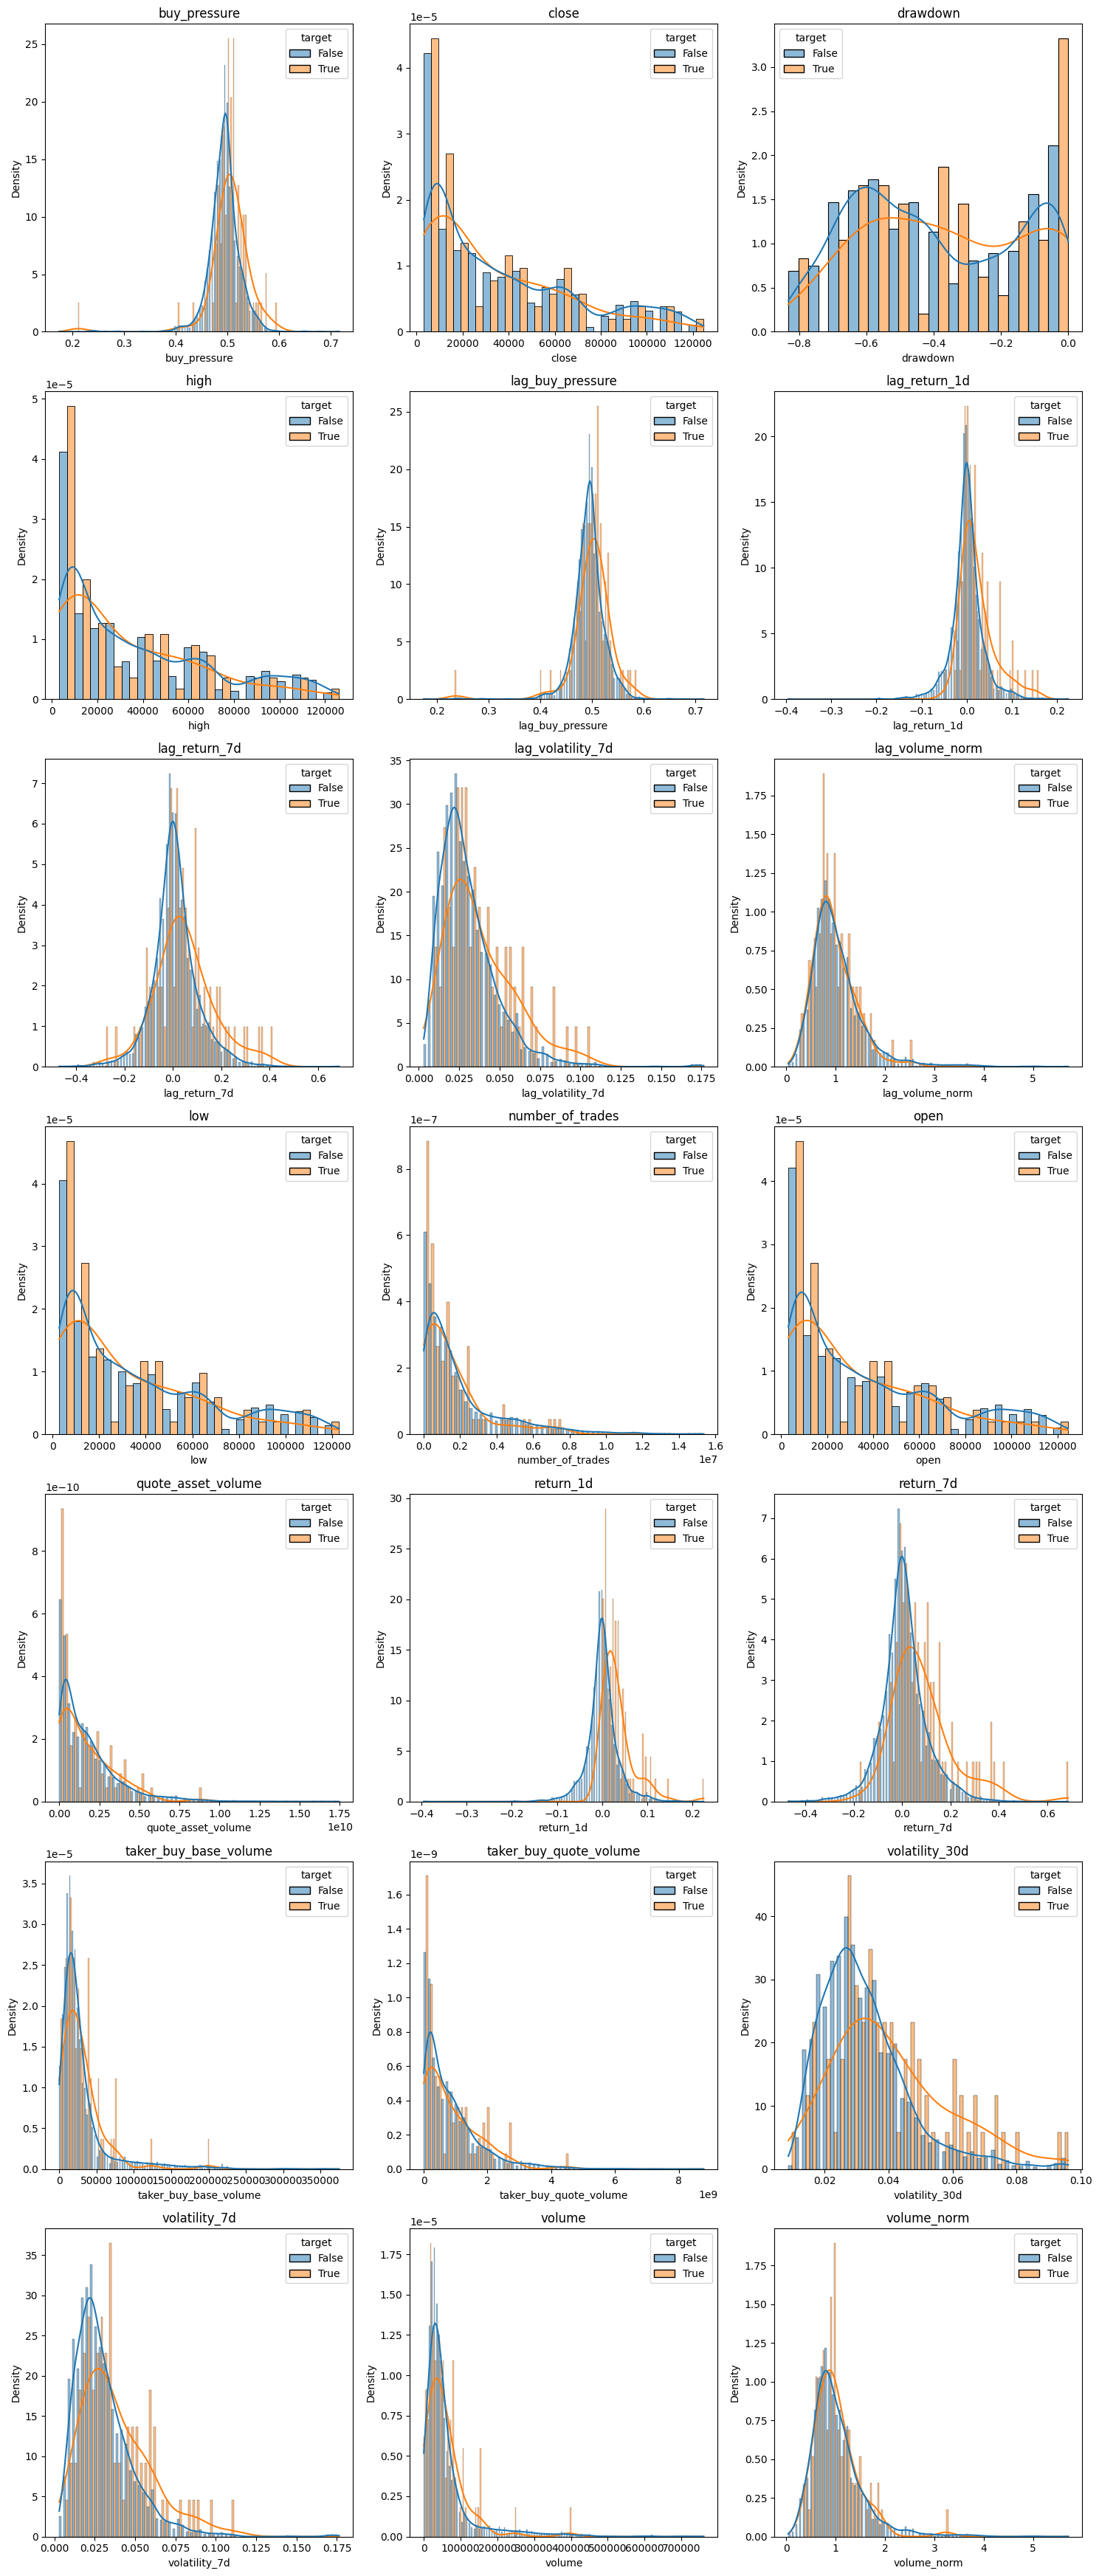

In [53]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        multiple="dodge",
        ax=axes[i],
        stat="density",
        common_norm=False,
        kde=True
        )
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations**

- Most features show **strong overlap between target classes**, indicating low separability when used individually.
- Returns (`return_1d`, `return_7d`, lagged) are **slightly shifted positive for target=True**, suggesting upward momentum before peaks.
- Volatility features are **higher for target=True**, indicating peaks occur in more unstable market conditions.
- `drawdown` is more concentrated near **0 for target=True**, meaning price is close to its **running historical maximum**.
- Volume-related features show **heavier tails for target=True**, suggesting increased market activity before peaks.
- Lagged features exhibit similar patterns to original ones → confirms **strong temporal dependence**.
- `buy_pressure` shows minimal difference → **weak standalone signal**.


**Conclusion**

- **Drawdown, volatility, and returns are key signals** for peak detection.  
- **Momentum + high volatility + proximity to historical highs** characterize peak regimes.  
- Volume features can help but require **log scaling and outlier handling**.  
- Individual features are weak → need **non-linear models combining signals** (e.g., tree-based).  
- Strong temporal structure → **lag features and time-aware modeling are essential**.  

Detect unusual behavior before peaks

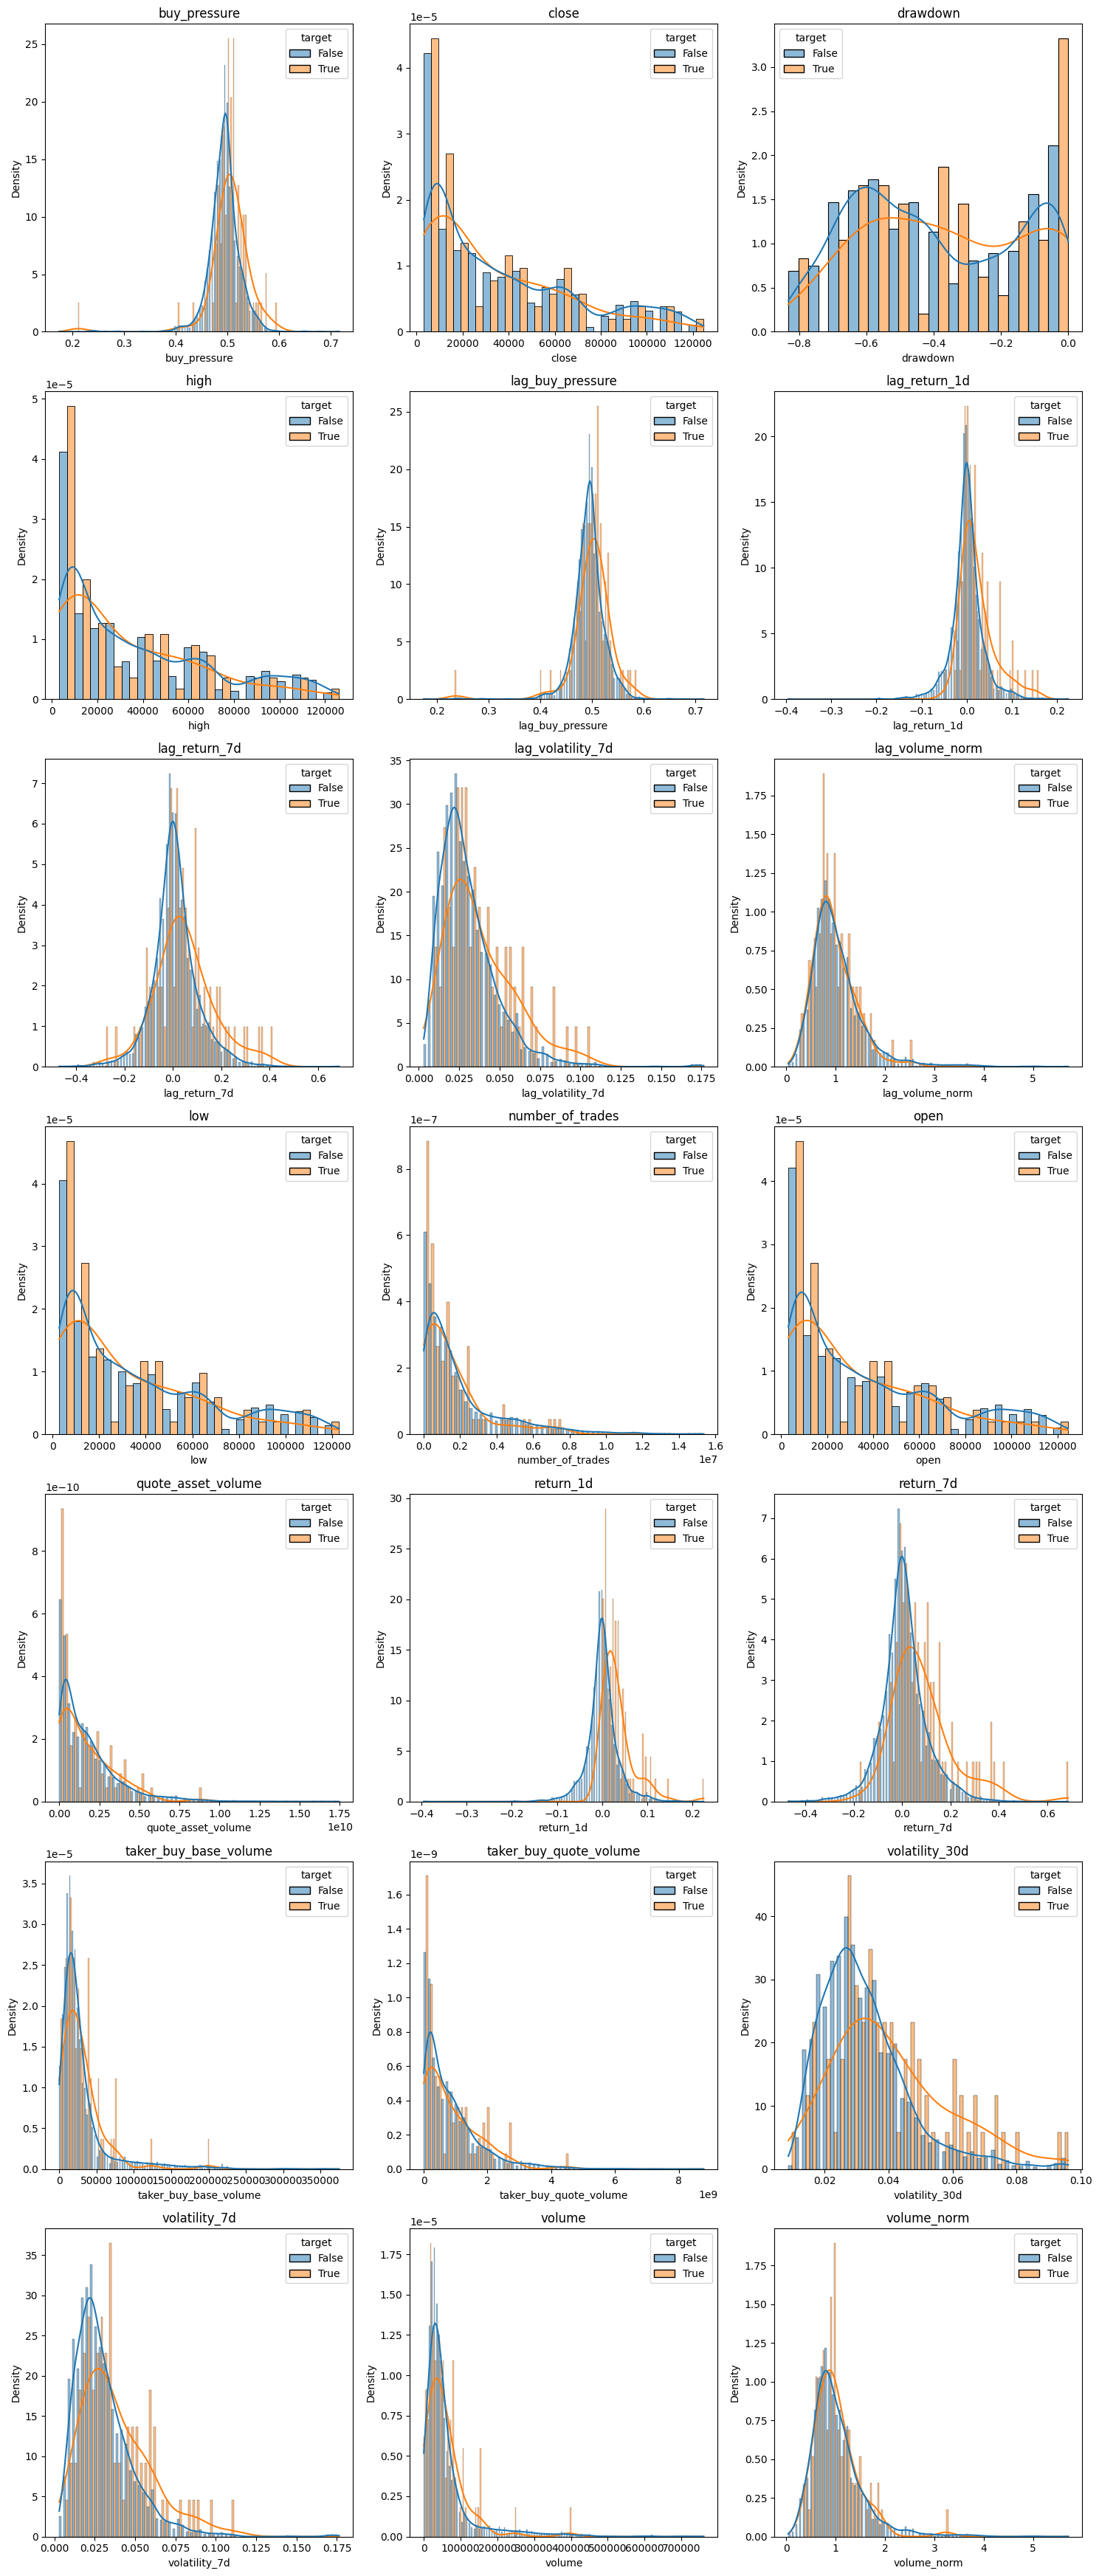

In [54]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        multiple="dodge",
        ax=axes[i],
        stat="density",
        common_norm=False,
        kde=True
        )
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Detect unusual behavior before peaks**

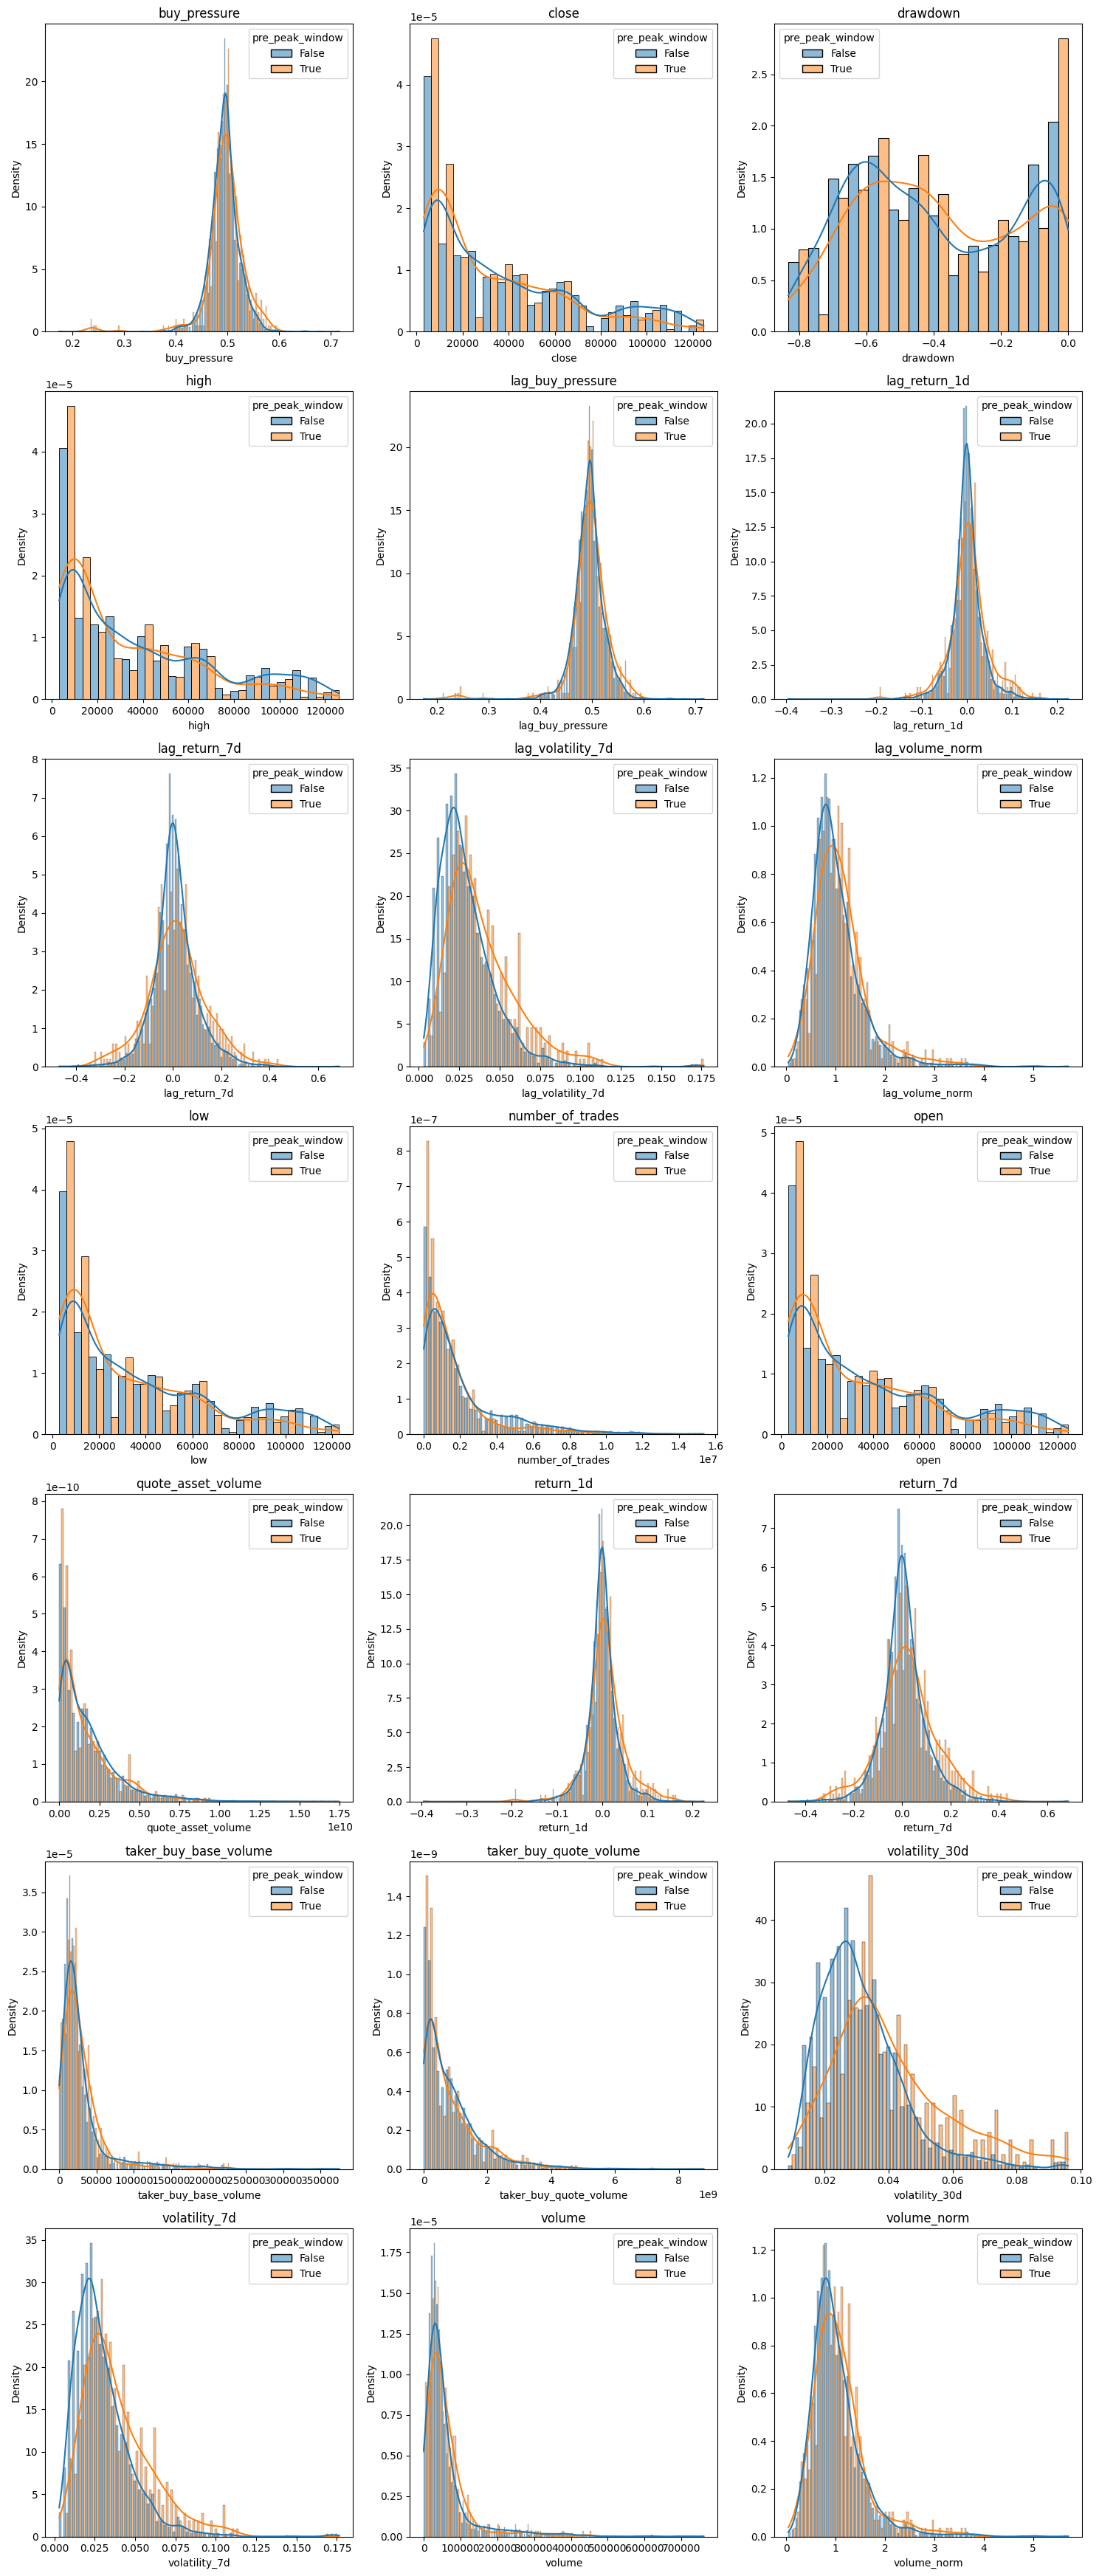

In [56]:
df["pre_peak_window"] = df["target"].shift(-1) | df["target"].shift(-2) | df["target"].shift(-3) | df["target"].shift(-4) | df["target"].shift(-5)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=df,
        x=col,
        hue="pre_peak_window",
        multiple="dodge",
        ax=axes[i],
        stat="density",
        common_norm=False,
        kde=True
        )
    axes[i].set_title(col)

# Supprimer les plots vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations**

- Most features still show **significant overlap** between normal and pre-peak periods → weak standalone signals.
- Returns (`return_1d`, `return_7d`, lagged) are **slightly more positive before peaks**, indicating momentum buildup.
- Volatility (`volatility_7d`, `volatility_30d`) is **clearly higher and more spread out before peaks** → strong instability signal.
- `drawdown` shifts **closer to 0 before peaks**, confirming peaks occur near historical highs.
- Volume-related features show **heavier right tails before peaks** → increased trading activity and possible FOMO.
- Lagged features reinforce the same patterns → **temporal persistence of signals**.
- `buy_pressure` remains very similar → **low discriminative power**.

**Conclusion**

- **Volatility is the strongest early warning signal** of upcoming peaks.  
- **Momentum (returns)** plays a secondary but consistent role.  
- **Proximity to highs (drawdown ≈ 0)** is a key structural condition.  
- Volume contributes but requires **careful preprocessing**.  
- Signals are **subtle and overlapping**, requiring **non-linear models and feature interactions**.  
- The problem is inherently **temporal**, making lag features essential.  

### **5.  Correlation between features and target**

Compute correlation between features and target

Identify features most related to peaks

Analyze direction of relationships (positive/negative)

Detect redundancy between features

Select most relevant features for modeling